# Cross-signal comparison: all 13 signals together

Notebook 02 looked at the seven Weekend 1 + Weekend 2 batch 1 consumer-amenity signals. Notebook 03 looked at the six Weekend 2 batch 2 production-side signals. This notebook is the synthesis: it does *not* re-run per-signal analyses, it asks questions that span both groups and all four signal classes.

The four signal classes, after the post-batch revisions:

- **leading** (7 signals): high-velocity, high-churn, hypothesized to predict neighborhood change. yoga_studios, specialty_coffee, wine_bars, pilates_studios, contractors, design_economy, real_estate_brokerages.
- **counter** (2 signals): incumbent businesses being displaced. auto_repair, print_shops.
- **anchor** (1 signal): rare, high-information events. whole_foods_openings.
- **coincident** (3 signals): indicators of established affluence or activity, not predictive. construction_companies, landscaping, skilled_trades.

Three cross-signal questions in scope:
1. Do leading-class openings actually precede counter-class closures (the core gentrification thesis)?
2. Which categories are durable vs which churn fast (5-year survival ranking)?
3. Do neighborhood trajectories show the predicted pattern (leading-class growth → counter-class decline) in gentrifying areas (Mount Pleasant) but not in stable ones (Marpole)?

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from datetime import date
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from signals.leading.yoga_studios import get_signal as get_yoga
from signals.leading.specialty_coffee import get_signal as get_coffee
from signals.leading.wine_bars import get_signal as get_wine
from signals.leading.pilates_studios import get_signal as get_pilates
from signals.leading.contractors import get_signal as get_contractors
from signals.leading.design_economy import get_signal as get_design
from signals.leading.real_estate_brokerages import get_signal as get_real_estate
from signals.counter.auto_repair import get_signal as get_auto
from signals.counter.print_shops import get_signal as get_print
from signals.anchor.whole_foods_openings import get_signal as get_wf
from signals.coincident.construction_companies import get_signal as get_construction
from signals.coincident.landscaping import get_signal as get_landscaping
from signals.coincident.skilled_trades import get_signal as get_trades
from signals.analytics import n_year_survival_rate
from viz.style import apply as apply_style, signal_color, class_color

apply_style()

CHART_DIR = ROOT / 'analysis' / 'composite_index' / 'weekend_2_charts'
CHART_DIR.mkdir(parents=True, exist_ok=True)

con = duckdb.connect(str(ROOT / 'vancouver_signals.duckdb'), read_only=True)

SIGNALS = {
    'yoga_studios': get_yoga,
    'specialty_coffee': get_coffee,
    'wine_bars': get_wine,
    'pilates_studios': get_pilates,
    'contractors': get_contractors,
    'design_economy': get_design,
    'real_estate_brokerages': get_real_estate,
    'auto_repair': get_auto,
    'print_shops': get_print,
    'whole_foods_openings': get_wf,
    'construction_companies': get_construction,
    'landscaping': get_landscaping,
    'skilled_trades': get_trades,
}

data = {name: fn(con).filter(~pl.col('is_left_censored')) for name, fn in SIGNALS.items()}
for name, df in data.items():
    print(f'  loaded {name}: {df.height:,}')

  loaded yoga_studios: 154
  loaded specialty_coffee: 1,292
  loaded wine_bars: 24
  loaded pilates_studios: 55
  loaded contractors: 6,922
  loaded design_economy: 4,215
  loaded real_estate_brokerages: 2,396
  loaded auto_repair: 1,248
  loaded print_shops: 448
  loaded whole_foods_openings: 3
  loaded construction_companies: 3,801
  loaded landscaping: 1,658
  loaded skilled_trades: 6,926


## Master signal table

In [2]:
rows = []
for name, fn in SIGNALS.items():
    df = fn(con)
    rows.append({
        'signal': name,
        'class': df['signal_class'].unique().to_list()[0],
        'total': df.height,
        'pct_left_censored': round(100 * df['is_left_censored'].sum() / df.height, 1) if df.height else 0,
        'pct_with_closure': round(100 * df['closure_date'].is_not_null().sum() / df.height, 1) if df.height else 0,
    })
class_order = {'leading': 0, 'counter': 1, 'anchor': 2, 'coincident': 3}
master = (pl.DataFrame(rows)
            .with_columns(pl.col('class').replace_strict(class_order, return_dtype=pl.Int32).alias('_co'))
            .sort(['_co', 'signal']).drop('_co'))
with pl.Config(tbl_cols=-1, tbl_rows=20):
    print(master)

shape: (13, 5)
┌────────────────────────┬────────────┬───────┬───────────────────┬──────────────────┐
│ signal                 ┆ class      ┆ total ┆ pct_left_censored ┆ pct_with_closure │
│ ---                    ┆ ---        ┆ ---   ┆ ---               ┆ ---              │
│ str                    ┆ str        ┆ i64   ┆ f64               ┆ f64              │
╞════════════════════════╪════════════╪═══════╪═══════════════════╪══════════════════╡
│ contractors            ┆ leading    ┆ 7501  ┆ 7.7               ┆ 10.5             │
│ design_economy         ┆ leading    ┆ 4942  ┆ 14.7              ┆ 22.2             │
│ pilates_studios        ┆ leading    ┆ 55    ┆ 0.0               ┆ 25.5             │
│ real_estate_brokerages ┆ leading    ┆ 2786  ┆ 14.0              ┆ 26.5             │
│ specialty_coffee       ┆ leading    ┆ 1352  ┆ 4.4               ┆ 53.8             │
│ wine_bars              ┆ leading    ┆ 25    ┆ 4.0               ┆ 60.0             │
│ yoga_studios           ┆ l

## Cross-class velocity

Aggregate openings and closures per year, grouped by signal class. The gentrification thesis predicts leading-class openings should peak before counter-class closures.

  saved analysis/composite_index/weekend_2_charts/cross_openings_by_class.png


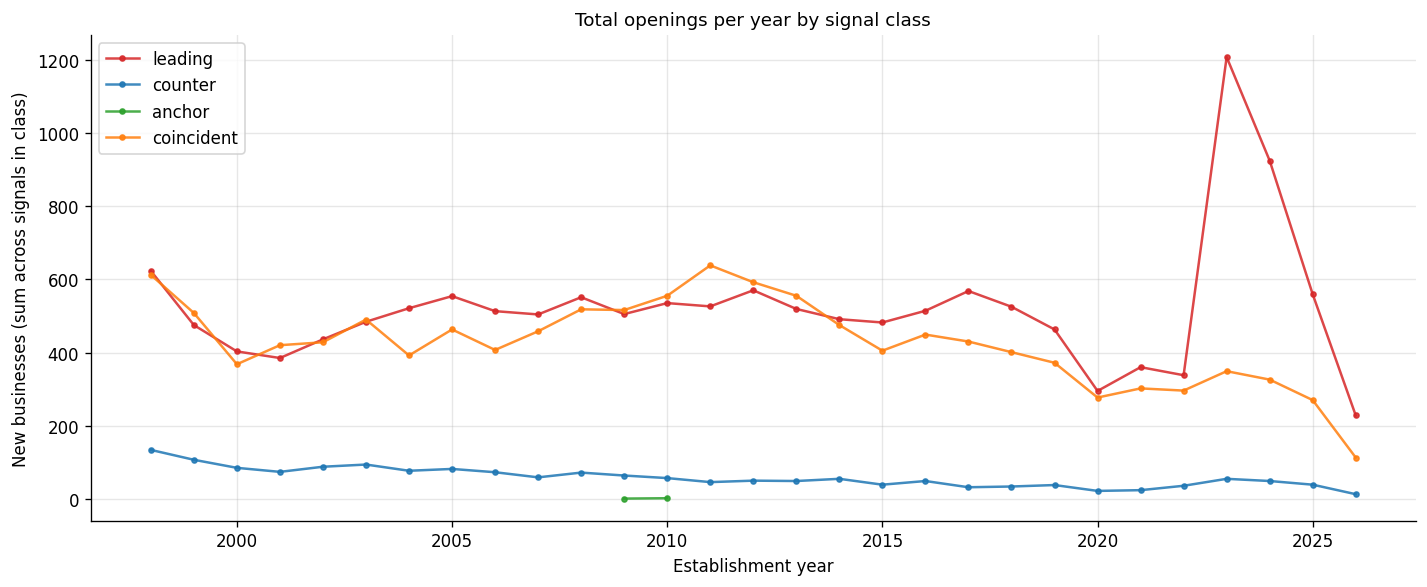

In [3]:
by_class = {}
for name, df in data.items():
    cls = df['signal_class'].unique().to_list()[0]
    yearly = (df.with_columns(pl.col('establishment_date').dt.year().alias('year'))
                .group_by('year').len().sort('year'))
    by_class.setdefault(cls, []).append(yearly)

fig, ax = plt.subplots(figsize=(12, 5))
for cls in ('leading', 'counter', 'anchor', 'coincident'):
    if cls not in by_class:
        continue
    combined = pl.concat(by_class[cls]).group_by('year').agg(pl.col('len').sum()).sort('year')
    ax.plot(combined['year'], combined['len'], label=cls, color=class_color(cls), marker='o', markersize=3, alpha=0.85)
ax.set_title('Total openings per year by signal class')
ax.set_xlabel('Establishment year')
ax.set_ylabel('New businesses (sum across signals in class)')
ax.legend(fontsize=10, loc='upper left')
fig.tight_layout()
out = CHART_DIR / 'cross_openings_by_class.png'
fig.savefig(out, bbox_inches='tight')
print(f'  saved {out.relative_to(ROOT)}')
plt.show()

  saved analysis/composite_index/weekend_2_charts/cross_closures_by_class.png


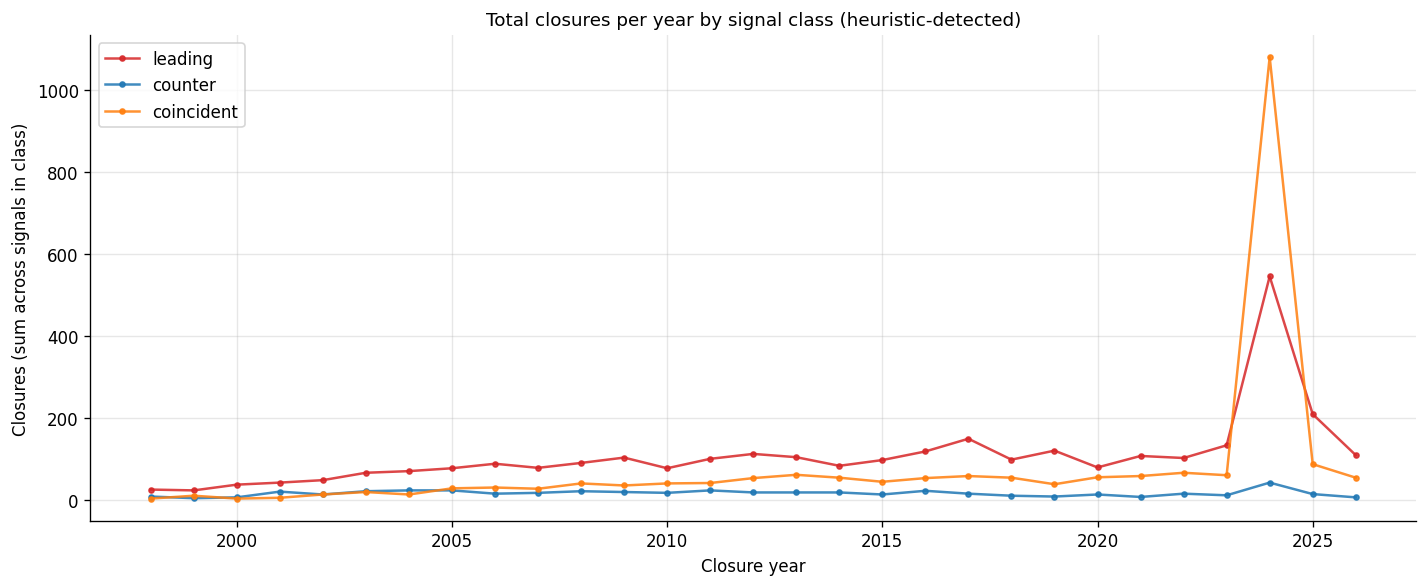

In [4]:
by_class_close = {}
for name, df in data.items():
    cls = df['signal_class'].unique().to_list()[0]
    closed = df.filter(pl.col('closure_date').is_not_null())
    if closed.height == 0:
        continue
    yearly = (closed.with_columns(pl.col('closure_date').dt.year().alias('year'))
                    .group_by('year').len().sort('year'))
    by_class_close.setdefault(cls, []).append(yearly)

fig, ax = plt.subplots(figsize=(12, 5))
for cls in ('leading', 'counter', 'anchor', 'coincident'):
    if cls not in by_class_close:
        continue
    combined = pl.concat(by_class_close[cls]).group_by('year').agg(pl.col('len').sum()).sort('year')
    ax.plot(combined['year'], combined['len'], label=cls, color=class_color(cls), marker='o', markersize=3, alpha=0.85)
ax.set_title('Total closures per year by signal class (heuristic-detected)')
ax.set_xlabel('Closure year')
ax.set_ylabel('Closures (sum across signals in class)')
ax.legend(fontsize=10, loc='upper left')
fig.tight_layout()
out = CHART_DIR / 'cross_closures_by_class.png'
fig.savefig(out, bbox_inches='tight')
print(f'  saved {out.relative_to(ROOT)}')
plt.show()

## 5-year survival ranking, all 13 signals

shape: (13, 4)
┌────────────────────────┬────────────┬───────┬─────────┐
│ signal                 ┆ class      ┆ total ┆ pct_5yr │
│ ---                    ┆ ---        ┆ ---   ┆ ---     │
│ str                    ┆ str        ┆ i64   ┆ f64     │
╞════════════════════════╪════════════╪═══════╪═════════╡
│ whole_foods_openings   ┆ anchor     ┆ 3     ┆ 100.0   │
│ construction_companies ┆ coincident ┆ 3317  ┆ 93.4    │
│ contractors            ┆ leading    ┆ 5242  ┆ 92.8    │
│ landscaping            ┆ coincident ┆ 1534  ┆ 91.3    │
│ skilled_trades         ┆ coincident ┆ 6180  ┆ 90.8    │
│ …                      ┆ …          ┆ …     ┆ …       │
│ print_shops            ┆ counter    ┆ 402   ┆ 79.1    │
│ real_estate_brokerages ┆ leading    ┆ 1588  ┆ 76.6    │
│ pilates_studios        ┆ leading    ┆ 29    ┆ 69.0    │
│ wine_bars              ┆ leading    ┆ 21    ┆ 61.9    │
│ specialty_coffee       ┆ leading    ┆ 1139  ┆ 49.3    │
└────────────────────────┴────────────┴───────┴─────────┘

  saved analysis/composite_index/weekend_2_charts/cross_5yr_survival_ranking.png


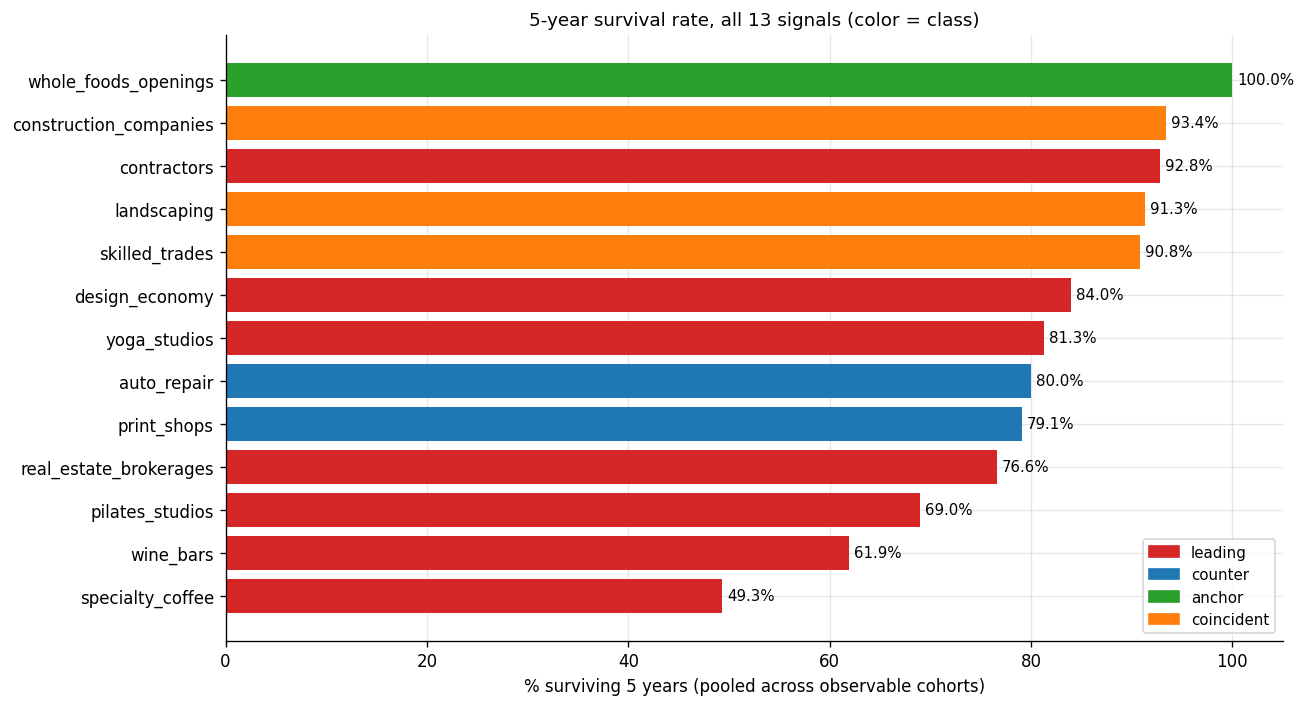

In [5]:
rows = []
for name, df in data.items():
    surv = n_year_survival_rate(df, n_years=5)
    if surv.height == 0:
        continue
    pooled_total = int(surv['n_total'].sum())
    pooled_alive = int(surv['n_surviving_at_n'].sum())
    rows.append({'signal': name, 'class': df['signal_class'].unique().to_list()[0],
                 'total': pooled_total, 'pct_5yr': round(100 * pooled_alive / pooled_total, 1) if pooled_total else 0})
ranking = pl.DataFrame(rows).sort('pct_5yr', descending=True)
print(ranking)

fig, ax = plt.subplots(figsize=(11, 6))
names = ranking['signal'].to_list()
vals = ranking['pct_5yr'].to_list()
classes = ranking['class'].to_list()
colors = [class_color(c) for c in classes]
ax.barh(names[::-1], vals[::-1], color=colors[::-1])
for i, v in enumerate(vals[::-1]):
    ax.text(v + 0.5, i, f'{v}%', va='center', fontsize=9)
# Legend by class
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=class_color(c), label=c) for c in ('leading', 'counter', 'anchor', 'coincident')],
          loc='lower right', fontsize=9)
ax.set_title('5-year survival rate, all 13 signals (color = class)')
ax.set_xlabel('% surviving 5 years (pooled across observable cohorts)')
ax.set_xlim(0, 105)
fig.tight_layout()
out = CHART_DIR / 'cross_5yr_survival_ranking.png'
fig.savefig(out, bbox_inches='tight')
print(f'  saved {out.relative_to(ROOT)}')
plt.show()

## Cohort-effect cross-signal comparison

The Weekend 2 finding from notebook 02 was that the 2008-2014 specialty-coffee survival cliff appeared in every neighborhood (time effect dominated place effect). Test whether the same time-window cliff appears in *other* signals — i.e., is the macro-vintage effect signal-specific or universal?

Five signals chosen: yoga (small but durable consumer amenity), specialty_coffee (the original cliff signal), contractors (production side leading), auto_repair (counter), landscaping (coincident wealth).

  saved analysis/composite_index/weekend_2_charts/cross_cohort_effect_selected.png


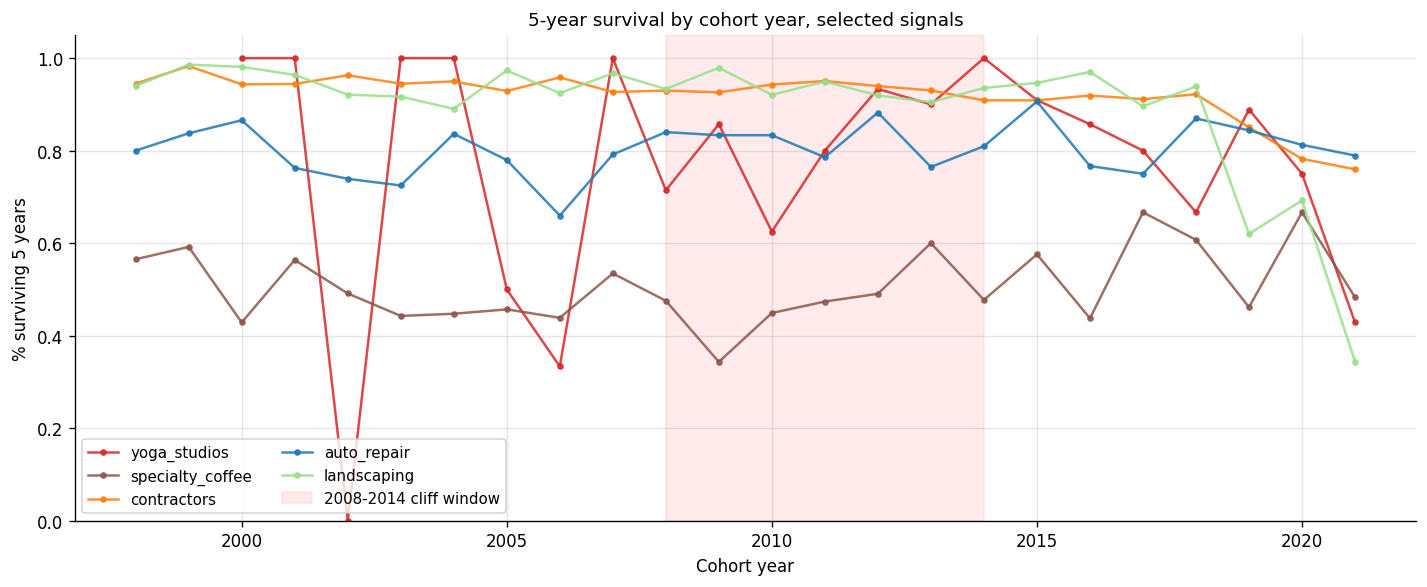

In [6]:
selected = ['yoga_studios', 'specialty_coffee', 'contractors', 'auto_repair', 'landscaping']
fig, ax = plt.subplots(figsize=(12, 5))
for name in selected:
    df = data[name]
    surv = n_year_survival_rate(df, n_years=5)
    if surv.height < 3:
        continue
    ax.plot(surv['cohort_year'], surv['pct_surviving_at_n'],
            label=name, color=signal_color(name), marker='o', markersize=3, alpha=0.85)
ax.axvspan(2008, 2014, color='red', alpha=0.08, label='2008-2014 cliff window')
ax.set_title('5-year survival by cohort year, selected signals')
ax.set_xlabel('Cohort year')
ax.set_ylabel('% surviving 5 years')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9, loc='lower left', ncol=2)
fig.tight_layout()
out = CHART_DIR / 'cross_cohort_effect_selected.png'
fig.savefig(out, bbox_inches='tight')
print(f'  saved {out.relative_to(ROOT)}')
plt.show()

## Neighborhood drill-down: Mount Pleasant vs Kitsilano vs Marpole

Active business count by signal class, over time, in each neighborhood. "Active in year Y" = established by year Y AND not closed by year Y. Three small multiples (one per neighborhood), four lines per chart (one per class).

Caveat: this aggregates across signals within each class, so it's biased toward classes with denser signals (leading has 7 signals; anchor has 1). The shapes are still readable; the absolute values are not directly comparable across classes.

  saved analysis/composite_index/weekend_2_charts/cross_neighborhood_active_by_class.png


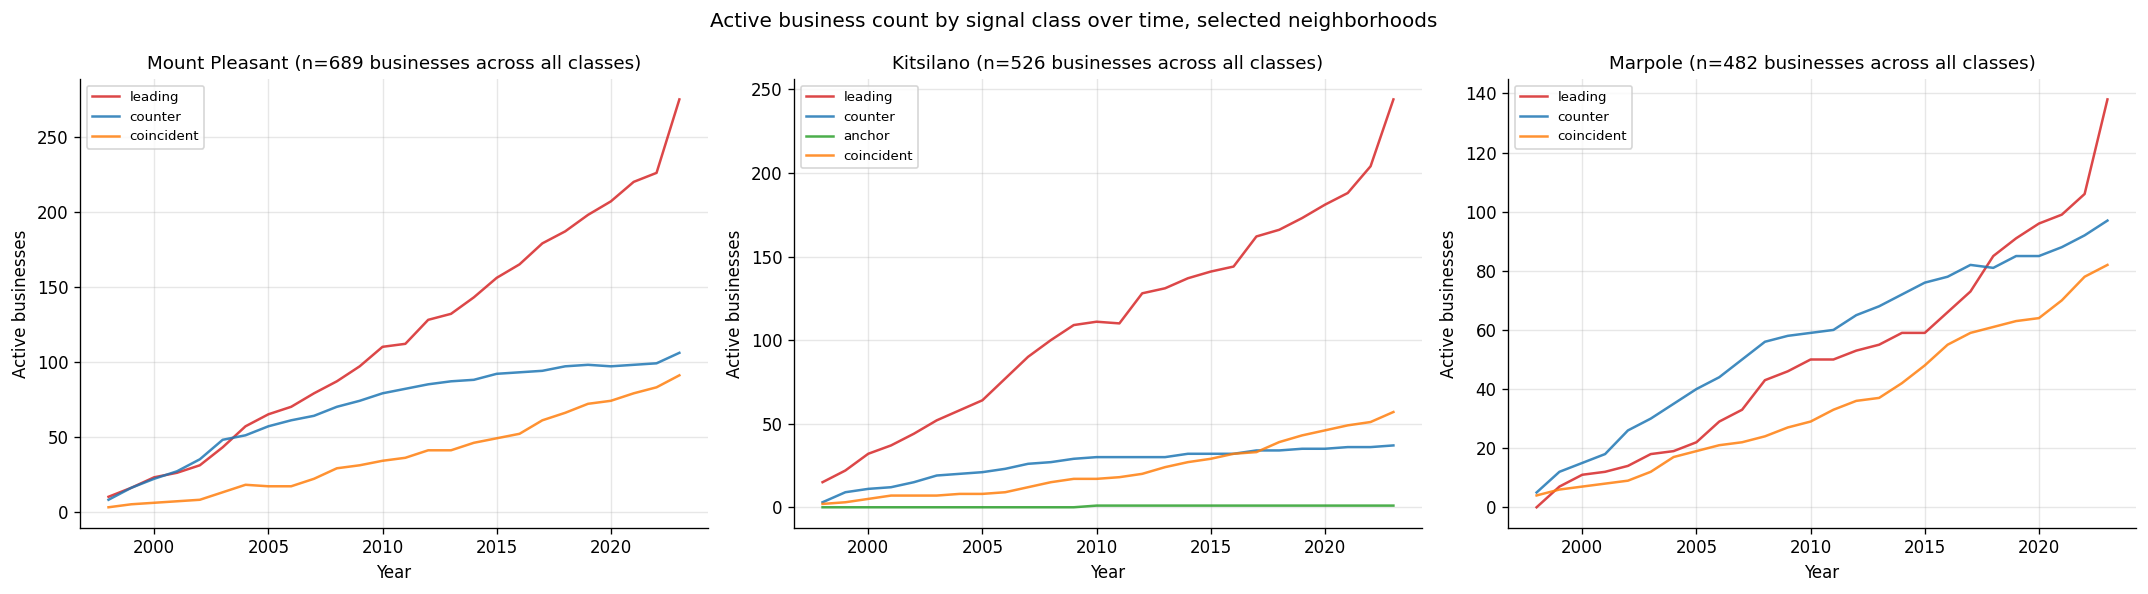

In [7]:
# Build a single long-form DF: business_id, class, neighborhood, established, closed (all dates).
frames = []
for name, df in data.items():
    cls = df['signal_class'].unique().to_list()[0]
    sub = df.select(['business_id', 'neighborhood', 'establishment_date', 'closure_date']).with_columns(pl.lit(cls).alias('signal_class'))
    frames.append(sub)
long = pl.concat(frames, how='vertical_relaxed')

NEIGHBORHOODS = ['Mount Pleasant', 'Kitsilano', 'Marpole']
today_year = date.today().year
years = list(range(1998, today_year - 2))  # cap at today-3 to avoid right-censoring artifacts

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
for ax, hood in zip(axes, NEIGHBORHOODS):
    sub = long.filter(pl.col('neighborhood') == hood)
    for cls in ('leading', 'counter', 'anchor', 'coincident'):
        cls_df = sub.filter(pl.col('signal_class') == cls)
        if cls_df.height == 0:
            continue
        active_per_year = []
        for y in years:
            active = cls_df.filter(
                (pl.col('establishment_date').dt.year() <= y) &
                (pl.col('closure_date').is_null() | (pl.col('closure_date').dt.year() > y))
            ).height
            active_per_year.append(active)
        ax.plot(years, active_per_year, label=cls, color=class_color(cls), alpha=0.85, linewidth=1.5)
    ax.set_title(f'{hood} (n={sub.height} businesses across all classes)')
    ax.set_xlabel('Year')
    ax.set_ylabel('Active businesses')
    ax.legend(fontsize=8, loc='upper left')
fig.suptitle('Active business count by signal class over time, selected neighborhoods')
fig.tight_layout()
out = CHART_DIR / 'cross_neighborhood_active_by_class.png'
fig.savefig(out, bbox_inches='tight')
print(f'  saved {out.relative_to(ROOT)}')
plt.show()

## Findings

(Filled in after reviewing the charts. Key questions:)

1. **Class-level velocity comparison.** Does the leading-class openings curve peak before the counter-class closures curve? If yes (with a 3-7 year lag), the gentrification thesis has at least surface plausibility. If they move together, the leading/counter naming is more about category type than temporal precedence.
2. **5-year survival ranking.** Does the order go: anchor > coincident > counter > leading? The hypothesis was that leading signals (frontier categories) would be more volatile than coincident signals (wealth indicators). The notebook 02 finding that yoga is more durable than auto repair complicates this; the full 13-signal ranking will reveal whether yoga was an outlier or a pattern.
3. **2008-2014 cohort cliff universality.** Does the cliff visible in specialty coffee appear in yoga? In auto repair? In contractors? If only coffee, the cliff is signal-specific (something about coffee shops in particular got hammered). If it appears across signals, the cliff is macro-vintage and any analysis spanning that window has to control for it.
4. **Neighborhood divergence.** In Mount Pleasant, did leading-class active counts grow earlier and faster than in Marpole? Does Mount Pleasant show counter-class decline (auto repair, print shops) before Marpole? If yes, the neighborhood-level gentrification framing has support. If the trajectories look similar, the macro-vintage effect dominates the place effect — same finding as the coffee analysis at 13-signal scale.

**What the cross-signal view confirms about the original hypothesis:**
(Filled in after seeing the charts.)

**What it complicates:**
(Filled in.)

**What can't be answered with current data:**
- Where is construction *actually happening*? Building-permit data, not licence data.
- What's the cause of cohort-level survival cliffs? Need macro time-series (Vancouver rents, BoC rates, BC housing transactions).
- Demographic / income context for each neighborhood: need StatsCan census tract data.
- Per-neighborhood property value: need BC Assessment data.

These are the next-tier data sources to bring in before any composite-index work that wants to make causal claims.